# Análisis Exploratorio de Datos

In [1]:
import sys
from pathlib import Path
import io
import os
import base64
import numpy as np
import pywt
import pandas as pd
from statsmodels.tsa import seasonal
import matplotlib.transforms as mtransforms
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, HTML
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss

PROJECT_ROOT = Path.cwd().parent
SRC_PATH     = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "data" / "raw" / "brent_raw.parquet"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

df = pd.read_parquet(DATA_PATH)

In [8]:
import numpy as np
import pandas as pd


def hampel_filter_power_from_matrix(power, dates, window_size=20, n_sigmas=3.0,
                                    mad_floor=1e-8, min_deviation=1e-4):
    """
    Filtro de Hampel robusto sobre la potencia wavelet promedio en escalas.

    Parámetros
    ----------
    power : np.ndarray
        Matriz de potencia wavelet de forma (n_escalas, n_obs).
    dates : pd.DatetimeIndex
        Índice temporal de las observaciones.
    window_size : int
        Tamaño de la ventana móvil (en número de observaciones).
    n_sigmas : float
        Número de MAD escaladas para el umbral.
    mad_floor : float
        Piso mínimo para el MAD.
    min_deviation : float o None
        Desviación mínima absoluta requerida para marcar outlier.

    Retorna
    -------
    outliers : pd.Series (bool)
        Serie booleana con True en las posiciones donde la potencia media se
        considera outlier.
    rolling_median : pd.Series
        Mediana móvil de la potencia media.
    threshold : pd.Series
        Umbral utilizado.
    """
    # Calcular la media aritmética de la potencia a lo largo de las escalas
    mean_power = np.mean(power, axis=0)          # shape (n_obs,)
    power_series = pd.Series(mean_power, index=dates)

    n = len(power_series)
    if n < window_size:
        raise ValueError("La serie es más corta que la ventana especificada.")

    # Mediana móvil centrada
    rolling_median = power_series.rolling(window=window_size, center=True).median()

    # Desviación absoluta respecto a la mediana local
    abs_deviation = (power_series - rolling_median).abs()

    # MAD (mediana de las desviaciones absolutas) en ventana móvil
    rolling_mad = abs_deviation.rolling(window=window_size, center=True).median()

    # Piso mínimo para el MAD
    rolling_mad_safe = rolling_mad.clip(lower=mad_floor)

    # Umbral robusto
    threshold = n_sigmas * 1.4826 * rolling_mad_safe

    # Condición de outlier
    if min_deviation is not None:
        outliers = (abs_deviation > threshold) & (abs_deviation > min_deviation)
    else:
        outliers = abs_deviation > threshold

    return outliers, rolling_median, threshold

from IPython.display import SVG, display

def render_figure_vector(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="svg", bbox_inches="tight")
    plt.close(fig)
    svg_data = buf.getvalue().decode("utf-8")
    display(HTML(
        f'<div style="display: flex; justify-content: center; width: 100%;">'
        f'{svg_data}</div>'
    ))

## Introducción

El precio del crudo Brent es una variable macroeconómica y financiera global con alta volatilidad y sensibilidad ante eventos geopolíticos. El modelado de varianza condicional en *commodities* evoluciona hacia arquitecturas híbridas que integran series temporales continuas con información no estructurada. La serie histórica de precios del contrato de futuro continuo del Brent proviene de Yahoo Finance. El contrato es un instrumento financiero estandarizado de negociación a plazo. Cotiza en bolsa y sirve de referencia global de precios.

:::{admonition} Información: Dataset de Futuros del Brent
:class: info

La serie analizada proviene del contrato de futuro continuo del petróleo crudo Brent (*ticker BZ=F* en Yahoo Finance). Incluye la estructura de precios diarios OHLC (apertura, máximo, mínimo y cierre) y el volumen de negociación. Comprende 3,154 observaciones en días hábiles de mercado (*business days*). Abarca múltiples regímenes y shocks estructurales. Los shocks incluyen la crisis de exceso de oferta (2014–2016), las tensiones geopolíticas y sanciones entre Estados Unidos e Irán, el colapso de demanda por COVID‑19 (2020) y los conflictos geopolíticos recientes.
:::

Las series financieras plantean heterocedasticidad condicional, colas pesadas, cambios estructurales de régimen y propagación de shocks exógenos no anticipados. El Análisis Exploratorio de Datos (EDA) constituye una fase crítica de validación e inferencia cuyo propósito es caracterizar la dinámica estocástica de la serie temporal antes de las fases de modelado de la volatilidad.

Esta libreta documenta la evaluación de la integridad de la base de datos: detección de registros faltantes, discontinuidades en el calendario de cotización bursátil y tratamiento de anomalías. También documenta el análisis de raíz unitaria, estacionariedad, propiedades distributivas y estructura de autocorrelación en media y varianza (efectos ARCH). Se incorpora una descomposición multirresolución en el dominio tiempo‑frecuencia para identificar valores atípicos, cambios de régimen y patrones locales de volatilidad.

## Análisis preliminar

El conjunto de datos estuvo compuesto por 3,177 registros diarios correspondientes a días hábiles de mercado. El período abarcó desde el 2 de enero de 2014 hasta el 21 de agosto de 2026. Las cinco variables analizadas (apertura, máximo, mínimo, cierre y volumen) se almacenaron en formato `float32`. No se identificaron valores faltantes en ninguna de ellas.

In [3]:
df_integrity = pd.DataFrame(
    {
        "Variable": df.columns,
        "Tipo de Datos": [str(dtype) for dtype in df.dtypes],
        "Valores Faltantes": df.isnull().sum().values,
    }
)


def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x


format_dict_integrity = {
    "Valores Faltantes": lambda x: smart_format(x, "{:,.0f}")
}

styled_integrity = df_integrity.style.hide(axis="index").set_table_styles(
    [
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "th:first-child",
            "props": [("text-align", "left")],
        },
        {
            "selector": "td:first-child",
            "props": [("text-align", "left")],
        },
    ]
)

styled_integrity = styled_integrity.format(format_dict_integrity)
display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_integrity.to_html()
        + "</div>"
    )
)

Variable,Tipo de Datos,Valores Faltantes
close,float32,0
high,float32,0
low,float32,0
open,float32,0
volume,float32,0


El conjunto de datos se dividió en dos segmentos: entrenamiento y prueba. El segmento de entrenamiento incluyó 2,223 observaciones, del 2 de enero de 2014 al 3 de noviembre de 2022. El segmento de prueba incluyó 954 observaciones, del 4 de noviembre de 2022 al 21 de agosto de 2026. La proporción fue 70% para entrenamiento y 30% para prueba. El análisis exploratorio se realizó exclusivamente sobre el segmento de entrenamiento. El segmento de prueba no se procesó.

In [10]:
df = df.sort_index()
split_idx = int(len(df) * 0.70)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=300)

ax.set_title("Precio de cierre del petróleo Brent", fontsize=12, pad=15)

ax.axvline(
    x=df_test.index[0], color="black", linestyle=":", linewidth=1.0, alpha=0.8
)

ax.plot(df_train.index, df_train["close"], color="black", linewidth=1.0)
ax.plot(df_test.index, df_test["close"], color="black", linewidth=1.0)

xlim_orig = ax.get_xlim()

ax.fill_betweenx(
    y=[0, 1],
    x1=df_test.index[0],
    x2=df.index[-1] + pd.Timedelta(days=300),
    transform=ax.get_xaxis_transform(),
    color="lightgray",
    alpha=0.3,
)

ax.set_xlim(xlim_orig)

mid_train = df_train.index[len(df_train) // 2]
mid_test = df_test.index[len(df_test) // 2]

trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

ax.text(
    mid_train,
    0.80,
    "Entrenamiento",
    transform=trans,
    ha="center",
    va="bottom",
    fontsize=12,
    color="black",
)

ax.text(
    mid_test,
    0.80,
    "Prueba",
    transform=trans,
    ha="center",
    va="bottom",
    fontsize=12,
    color="black",
)

ax.set_xlabel("Fecha", fontsize=10, labelpad=7)
ax.set_ylabel("Precio (USD/bbl)", fontsize=10, labelpad=7)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="x",
    which="both",
    bottom=True,
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)
ax.tick_params(
    axis="y",
    which="both",
    left=True,
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
render_figure_vector(fig)

:::{admonition} Partición temporal
:class: info
La partición respetó el orden cronológico de los registros. No se aplicó barajado aleatorio. El conjunto de prueba funciona como *holdout set* y permanece intacto para evaluar el desempeño fuera de muestra. Esta estrategia evita la fuga de información entre los conjuntos.
:::

El precio de cierre constituyó la serie principal de referencia. Los retornos logarítmicos diarios se calcularon como $r_t = \ln(P_t/P_{t-1})$. La volatilidad se aproximó mediante dos proxies: los retornos al cuadrado $r_t^2$ y el estimador de rango de Garman‑Klass (GK). El estimador GK utiliza los precios de apertura, máximo, mínimo y cierre para representar la variabilidad intradía. Las series derivadas se calcularon sobre el segmento de entrenamiento.

In [11]:
term_hl = np.log(df_train['high'] / df_train['low']) ** 2
term_co = np.log(df_train['close'] / df_train['open']) ** 2
df_train['gk_daily'] = 0.511 * term_hl - (2 * np.log(2) - 1) * term_co

df_train["log_returns"] = np.log(df_train["close"] / df_train["close"].shift(1))
df_train["squared_returns"] = df_train["log_returns"] ** 2

cols_target = ["close", "log_returns", "squared_returns", "gk_daily"]
df_stats = df_train[cols_target].dropna()

Las estadísticas descriptivas indicaron asimetría positiva en el precio de cierre, con media superior a la mediana. Los retornos logarítmicos mostraron una media cercana a cero y valores extremos que sugieren colas pesadas. Las dos aproximaciones de volatilidad, retornos al cuadrado y estimador Garman‑Klass, presentaron medias y cuartiles próximos, lo que indica consistencia en la captura de la variabilidad diaria. La concentración de la masa en valores bajos frente a máximos elevados apuntan a un agrupamiento de volatilidad.

In [17]:
def get_stats_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return pd.Series(
        {
            "Registros": len(series),
            "Media": series.mean(),
            "Desv. Est.": series.std(),
            "Mínimo": series.min(),
            "Cuartil 1": q1,
            "Mediana": series.median(),
            "Cuartil 3": q3,
            "Máximo": series.max(),
            "IQR": iqr,
        }
    )

df_summary = df_stats.apply(get_stats_summary)

df_summary.columns = [
    "Precio de cierre",
    "Retornos logarítmicos",
    "Retornos al cuadrado",
    "Volatilidad realizada (GK)",
]

df_audit = df_summary.reset_index().rename(columns={"index": "Parámetro"})

numeric_cols = df_audit.columns[1:]
df_audit[numeric_cols] = df_audit[numeric_cols].map(lambda x: 0.0 if abs(x) < 0.00005 else x)

mask_registros = df_audit["Parámetro"] == "Registros"

styled_audit = (
    df_audit.style
    .hide(axis="index")
    .set_table_styles(
        [
            {
                "selector": "",
                "props": [
                    ("margin-left", "auto"),
                    ("margin-right", "auto"),
                    ("width", "auto"),
                    ("border-collapse", "collapse"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("background-color", "#f2f2f2"),
                    ("color", "black"),
                    ("font-weight", "bold"),
                    ("border", "1px solid black"),
                    ("padding", "10px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("vertical-align", "middle"),
                    ("border", "1px solid black"),
                    ("padding", "10px"),
                ],
            },
            {
                "selector": "th:first-child",
                "props": [
                    ("text-align", "left"),
                    ("vertical-align", "middle"),
                ],
            },
            {
                "selector": "td:first-child",
                "props": [
                    ("text-align", "left"),
                    ("vertical-align", "middle"),
                ],
            },
        ]
    )
    .format("{:,.0f}", subset=pd.IndexSlice[mask_registros, numeric_cols])
    .format("{:,.4f}", subset=pd.IndexSlice[~mask_registros, numeric_cols])
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_audit.to_html()
        + "</div>"
    )
)

Parámetro,Precio de cierre,Retornos logarítmicos,Retornos al cuadrado,Volatilidad realizada (GK)
Registros,"2,222","2,222","2,222","2,222"
Media,66.4671,-0.0001,0.0007,0.0006
Desv. Est.,21.6286,0.0259,0.0029,0.0022
Mínimo,19.3300,-0.2798,0.0000,0.0000
Cuartil 1,50.3650,-0.0104,0.0000,0.0001
Mediana,62.7350,0.0008,0.0001,0.0003
Cuartil 3,76.4975,0.0115,0.0005,0.0006
Máximo,127.9800,0.1908,0.0783,0.0658
IQR,26.1325,0.0220,0.0005,0.0004


Las estadísticas descriptivas no son representativas por sí solas de la dinámica de precios. No se evaluó la estacionariedad de las series. Una serie no estacionaria presenta media, varianza u otros momentos que dependen del tiempo; los valores descriptivos globales combinan regímenes distintos y no describen un periodo específico. Las próximas secciones presentan un análisis detallado de cada serie, su estacionariedad y posibles eventos atípicos. El EDA culmina con el estudio de la dependencia entre los retornos al cuadrado y el estimador Garman‑Klass para la volatilidad realizada.

:::{admonition} Nota: Estimador de Volatilidad de Garman‑Klass
:class: note

El estimador de rango de Garman‑Klass (GK) captura la variabilidad intradía sin depender únicamente de los precios de cierre. Integra la trayectoria diaria de apertura, máximo, mínimo y cierre ($O_t, H_t, L_t, C_t$). El estimador logra mayor eficiencia asintótica que la varianza basada en retornos de cierre a cierre; esto es: reduce la varianza del estimador al aprovechar la información intradía de precios en comparación con los retornos al cuadrado.

$$
GK_t = 0.511 \left(\ln \frac{H_t}{L_t}\right)^2 - (2\ln 2 - 1) \left(\ln \frac{C_t}{O_t}\right)^2
$$

Donde $H_t$, $L_t$, $O_t$ y $C_t$ representan el precio máximo, mínimo, apertura y cierre del día \(t\).
:::

## Precio de cierre

El precio de cierre presentó cuatro episodios de cambio de nivel y volatilidad. El colapso 2014–2016 llevó el precio desde 110 hasta 30 USD/bbl. El auge del petróleo de esquisto en EE.UU. y la defensa de cuotas de mercado por la OPEP estuvieron asociados al descenso. La recuperación 2017–2019 mantuvo el precio entre 50 y 80 USD/bbl. Los acuerdos de recorte OPEP+ respaldaron ese rango. El desplome pandémico de 2020 situó el precio cerca de 20 USD/bbl. El confinamiento global y la parálisis industrial redujeron la demanda. El rally post‑pandemia 2021–2022 superó los 120 USD/bbl. La reactivación económica y las tensiones geopolíticas en Europa del Este impulsaron el alza.

In [70]:
# Preparar datos
df_plot = df_train.copy()
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data = [df_plot[df_plot["year"] == yr]["close"].values for yr in years]

# Crear figura
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(8, 4),
    dpi=300,
)

# Estilo de ejes para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel izquierdo: serie temporal
ax1.plot(df_plot.index, df_plot["close"], color="black", linewidth=1.0)
ax1.set_xlabel("Fecha", fontsize=10, labelpad=7)
ax1.set_ylabel("Precio (USD/bbl)", fontsize=10, labelpad=7)
ax1.set_title("Precio de cierre", fontsize=12, pad=11)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Panel derecho: boxplot anual
bp = ax2.boxplot(
    box_data,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

# Eje X: mostrar solo años pares
even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=10, labelpad=7)
ax2.set_title("Distribución anual del precio", fontsize=12, pad=11)

# Ocultar eje Y en el boxplot
ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

# Renderizar figura en SVG centrada
plt.tight_layout()
render_figure_vector(fig)

Los diagramas de caja anuales no fueron homogéneos. La mediana y la amplitud intercuartílica variaron entre años. El año 2014 presentó una distribución asimétrica con valores atípicos en la cola inferior. El año 2016 mostró una caja compacta en precios de cierre más bajos. El año 2020 registró una mediana baja y valores atípicos superiores. El año 2022 desplazó la distribución hacia el segmento superior. Estos patrones sugirieron que la variabilidad del precio no fue constante en el tiempo. La variabilidad fue sensible a eventos macroeconómicos y geopolíticos.

Los diagramas de caja por mes y por día de la semana describieron la distribución del precio. Las medianas mensuales se ubicaron entre 60 y 70 USD/bbl. No se identificó un ciclo estacional definido. Los meses de enero a marzo concentraron valores atípicos en ambas colas. Los movimientos extremos fueron más frecuentes al inicio del año, cuando se concentran mantenimientos de refinerías y decisiones de la OPEP+.

In [72]:
import io
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def render_figure_vector(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="svg", bbox_inches="tight")
    plt.close(fig)
    svg_data = buf.getvalue().decode("utf-8")
    display(HTML(
        f'<div style="text-align: center; width: 100%;">'
        f'{svg_data}</div>'
    ))

# Preparar datos
df_plot = df_train.copy()

# Extraer mes y día de la semana
df_plot["month"] = df_plot.index.month
df_plot["weekday"] = df_plot.index.dayofweek  # 0=Lunes, 6=Domingo

months = list(range(1, 13))
month_data = [df_plot[df_plot["month"] == m]["close"].values for m in months]

weekdays = [0, 1, 2, 3, 4]
weekday_data = [df_plot[df_plot["weekday"] == wd]["close"].values for wd in weekdays]

month_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
weekday_labels = ["Lun", "Mar", "Mié", "Jue", "Vie"]

# Crear figura con dos paneles
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    dpi=300,
)

# Estilo de ejes para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# --- Panel izquierdo: Boxplot por mes ---
bp_month = ax1.boxplot(
    month_data,
    positions=months,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=9)
ax1.set_xlim(min(months) - 0.8, max(months) + 0.8)

ax1.set_xlabel("Mes", fontsize=10, labelpad=8)
ax1.set_title("Distribución mensual del precio", fontsize=12, pad=11)
ax1.set_ylabel("Precio (USD/bbl)", fontsize=10, labelpad=7)

# Panel izquierdo: mostrar eje Y
ax1.tick_params(
    axis="y",
    which="both",
    left=True,
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

# --- Panel derecho: Boxplot por día de la semana ---
bp_week = ax2.boxplot(
    weekday_data,
    positions=weekdays,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_xticks(weekdays)
ax2.set_xticklabels(weekday_labels, rotation=0, fontsize=9)
ax2.set_xlim(min(weekdays) - 0.8, max(weekdays) + 0.8)

ax2.set_xlabel("Día de la semana", fontsize=10, labelpad=8)
ax2.set_title("Distribución semanal del precio", fontsize=12, pad=11)

# Ocultar eje Y en el panel derecho
ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

Las distribuciones semanales de los días hábiles (lunes a viernes) mostraron medianas, rangos intercuartílicos y bigotes similares. Esta homogeneidad indicó ausencia de efecto día de la semana en el precio de cierre del Brent.

### Análisis de estacionariedad

La función de autocorrelación (ACF) del precio de cierre presentó decaimiento lento desde valores cercanos a 1 en el primer rezago. Las autocorrelaciones permanecieron por encima de la banda de confianza en los 50 rezagos evaluados. El patrón indicó persistencia temporal: el nivel actual mostró correlación con valores pasados distantes.

In [73]:
import io
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import display, HTML

def render_figure_vector(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="svg", bbox_inches="tight")
    plt.close(fig)
    svg_data = buf.getvalue().decode("utf-8")
    display(HTML(
        f'<div style="text-align: center; width: 100%;">'
        f'{svg_data}</div>'
    ))

# Usar datos de entrenamiento
series = df_train["close"].dropna()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    dpi=300,
    sharey=True,
)

# ACF
plot_acf(
    series,
    lags=50,
    ax=ax1,
    title="ACF",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

# PACF
plot_pacf(
    series,
    lags=50,
    ax=ax2,
    title="PACF",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

# Estilo uniforme para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    # Sombras de confianza
    for collection in ax.collections:
        collection.set_facecolor("lightgray")
        collection.set_alpha(0.3)

    # Líneas y marcadores
    for line in ax.lines:
        line.set_markerfacecolor("black")
        line.set_markeredgecolor("black")
        line.set_markersize(1.8)
        line.set_linewidth(0.8)

    # Título y etiquetas
    ax.set_title(ax.get_title(), fontsize=12, pad=11)
    ax.set_xlabel("Rezago", fontsize=10, labelpad=7)

    # Ticks eje X
    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

    # Ticks eje Y
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Eje Y solo en panel izquierdo
ax1.set_ylabel("Autocorrelación", fontsize=10, labelpad=7)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.tight_layout()
render_figure_vector(fig)

La función de autocorrelación parcial (PACF) presentó un valor alto en el primer rezago. Los rezagos posteriores mostraron valores cercanos a cero. El corte después del primer rezago indicó que la dependencia lineal directa se concentró en el primer retardo, una vez controlados los rezagos intermedios.

Los contrastes estadísticos respaldaron los resultados de la ACF y la PACF. La prueba ADF (*p* = .231) y la prueba KPSS (*p* = .010) indicaron que el precio de cierre en niveles no satisfizo la condición de estacionariedad. La serie presentó tendencia estocástica y no revirtió a una media constante. Las pruebas de Ljung‑Box rechazaron la hipótesis nula de ausencia de autocorrelación en los rezagos 10, 20 y 30 (*p* < .001). Estos resultados indicaron dependencia temporal en la serie en niveles.

In [132]:
import warnings
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

# Asegurar serie limpia
serie = df_train["close"].dropna()

# 1. Ejecutar pruebas estadísticas (con supresión local para KPSS)
adf_res = adfuller(serie, autolag="AIC")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    kpss_res = kpss(serie, regression="c", nlags="auto")

lb_res = acorr_ljungbox(serie, lags=[10, 20, 30], return_df=True)

# Función para omitir el cero inicial en los decimales (formato APA: .123 en vez de 0.123)
def format_apa_pvalue(val):
    if pd.isna(val):
        return ""
    if val < 0.001:
        return "< .001"
    formatted = f"{val:.3f}"
    if formatted.startswith("0."):
        return formatted[1:]
    return formatted

# 2. Construir la estructura de datos para la tabla
data_audit_inferencial = [
    {
        "Prueba": "Augmented Dickey-Fuller (ADF)",
        "Estadístico": adf_res[0],
        "p-valor": adf_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria"
            if adf_res[1] > 0.05
            else "Estacionaria"
        ),
    },
    {
        "Prueba": "KPSS (Kwiatkowski-Phillips)",
        "Estadístico": kpss_res[0],
        "p-valor": kpss_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria"
            if kpss_res[1] < 0.05
            else "Estacionaria"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 10)",
        "Estadístico": lb_res.loc[10, "lb_stat"],
        "p-valor": lb_res.loc[10, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa",
    },
    {
        "Prueba": "Ljung-Box (Lag 20)",
        "Estadístico": lb_res.loc[20, "lb_stat"],
        "p-valor": lb_res.loc[20, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa",
    },
    {
        "Prueba": "Ljung-Box (Lag 30)",
        "Estadístico": lb_res.loc[30, "lb_stat"],
        "p-valor": lb_res.loc[30, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa",
    },
]

df_inferencial = pd.DataFrame(data_audit_inferencial)

# Aplicar formato personalizado de p-valor
df_inferencial["p-valor"] = df_inferencial["p-valor"].apply(format_apa_pvalue)

# 3. Diccionario de formato numérico para el estadístico
def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_inf = {
    "Estadístico": lambda x: smart_format(x, "{:,.4f}"),
}

# 4. Estilos CSS idénticos a tu tabla de referencia
styled_inf = df_inferencial.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {"selector": "th:first-child", "props": [("text-align", "left")]},
    {"selector": "td:first-child", "props": [("text-align", "left")]},
])

styled_inf = styled_inf.format(format_dict_inf)

# 5. Renderizar en el notebook centrado
display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_inf.to_html()
        + "</div>"
    )
)

Prueba,Estadístico,p-valor,Conclusión (α = .05)
Augmented Dickey-Fuller (ADF),-2.1353,.231,No Estacionaria
KPSS (Kwiatkowski-Phillips),0.8490,.010,No Estacionaria
Ljung-Box (Lag 10),"21,430.1799",< .001,Autocorrelación Significativa
Ljung-Box (Lag 20),"41,467.1083",< .001,Autocorrelación Significativa
Ljung-Box (Lag 30),"59,936.1725",< .001,Autocorrelación Significativa


### Descomposición Multirresolución

Se aplicó una descomposición wavelet discreta con la wavelet Daubechies 4 (db4) y 7 niveles sobre la serie de precio de cierre del Brent. El componente de tendencia $A_7$ aisló la trayectoria de largo plazo. Eliminó las fluctuaciones de alta frecuencia. Reprodujo los episodios identificados en la inspección visual del precio. La tendencia sirvió como referencia del nivel subyacente del mercado. Los cambios de régimen no fueron oscilaciones de corto plazo. Fueron desplazamientos persistentes en la media de la serie.

:::{admonition} Nota: Descomposición Wavelet con db4
:class: note

La descomposición wavelet con Daubechies 4 (db4) representó la serie de precios como suma de una aproximación de baja frecuencia y varios detalles de alta frecuencia. La wavelet db4 posee soporte compacto y dos momentos de desvanecimiento. El soporte compacto permite localizar cambios en el tiempo. Los momentos de desvanecimiento permiten representar tendencias suaves con pocos coeficientes.

$$
P_t = A_J(t) + \sum_{j=1}^{J} D_j(t)
$$

Donde $A_J$ es la aproximación final y $D_j$ son los detalles en cada escala. La serie se descompuso en 7 niveles. La elección de db4 se fundamenta en su capacidad para capturar discontinuidades locales. La descomposición STL (*Seasonal-Trend decomposition using Loess*) separa componentes estacionales y de tendencia, pero asume estacionalidad fija. Los modelos aditivos o multiplicativos tradicionales también imponen una estructura rígida a la estacionalidad. La wavelet db4 no requiere supuestos sobre periodicidad fija. Esta flexibilidad resultó adecuada para estudiar la dinámica del precio del Brent.
:::

El componente de detalle $D_7$ osciló alrededor de cero. Capturó fluctuaciones de frecuencia intermedia. La amplitud de las oscilaciones no fue constante. Aumentó en períodos de tensión como 2014–2015 y el inicio de 2020. Se atenuó en intervalos de menor volatilidad como 2016–2017 y parte de 2021. Los ciclos de mediano plazo no siguieron un patrón fijo de calendario. Se modularon según las condiciones del mercado. Se amplificaron durante shocks macroeconómicos. Se contrajeron en fases de relativa estabilidad. La variación de la amplitud sugirió que la volatilidad de los retornos dependía de la escala del ciclo.

In [80]:
# Datos
df_plot = df_train.copy()
close_prices = df_plot["close"].values
n_obs = len(close_prices)

# Descomposición wavelet
wavelet = "db4"
level = 7
coeffs = pywt.wavedec(close_prices, wavelet, level=level)

c_trend = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
trend_A7 = pywt.waverec(c_trend, wavelet)[:n_obs]

c_ann = [np.zeros_like(c) for c in coeffs]
c_ann[1] = coeffs[1]   # D7
annual_D7 = pywt.waverec(c_ann, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "trend_A7": trend_A7,
        "annual_D7": annual_D7,
    },
    index=df_plot.index,
)

# Crear figura con dos paneles apilados
fig, (ax_tr, ax_ann) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    dpi=300,
    sharex=True,
)

# Estilo común de ejes
for ax in (ax_tr, ax_ann):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel superior: tendencia
ax_tr.plot(df_decomp_2p.index, df_decomp_2p["trend_A7"], color="black", linewidth=1.0)
ax_tr.set_title("Componente de tendencia", fontsize=12, pad=11, loc="left")
ax_tr.set_ylabel("Precio de cierre (USD/bbl)", fontsize=10, labelpad=7)

# Panel inferior: D7
ax_ann.plot(df_decomp_2p.index, df_decomp_2p["annual_D7"], color="black", linewidth=0.8)
ax_ann.set_title("Estacionalidad anualizada", fontsize=12, pad=11, loc="left")
ax_ann.set_ylabel("Desviación", fontsize=10, labelpad=7)
ax_ann.set_xlabel("Fecha", fontsize=10, labelpad=8)

# Formato del eje X solo en el panel inferior
ax_ann.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ann.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Ajuste de espacio entre paneles
fig.subplots_adjust(hspace=0.3)

# Renderizar en SVG
render_figure_vector(fig)

El componente semestral $D_6$ mostró un aumento de amplitud desde finales de 2018. Antes de ese período, las oscilaciones se mantuvieron en un rango aproximado de ±5 USD/bbl. Después de 2018, los picos alcanzaron valores cercanos a ±10 USD/bbl. La expansión coincidió con la recuperación del precio tras la depresión de 2014–2016 y con los recortes de producción de la OPEP+ de finales de 2018. La energía cíclica de mediano plazo se incrementó cuando el precio se situó en niveles más altos.

El componente trimestral $D_4 + D_5$ mostró sensibilidad a crisis puntuales. Las oscilaciones se comprimieron en períodos de calma. Se expandieron en pulsos de alta frecuencia durante la guerra de precios de 2015, el colapso de demanda por la COVID‑19 en 2020 y la dislocación energética de 2022. El componente trimestral concentró su energía en picos localizados. A diferencia del semestral, no presentó un cambio de régimen sostenido. La naturaleza transitoria de los shocks quedó reflejada en esos pulsos.

In [81]:
# Componente semestral (D6)
c_sem = [np.zeros_like(c) for c in coeffs]
c_sem[2] = coeffs[2]
estacionalidad_semestral = pywt.waverec(c_sem, wavelet)[:n_obs]

# Componente trimestral (D4 + D5)
c_trim = [np.zeros_like(c) for c in coeffs]
c_trim[3] = coeffs[3]
c_trim[4] = coeffs[4]
estacionalidad_trimestral = pywt.waverec(c_trim, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "estacionalidad_semestral": estacionalidad_semestral,
        "estacionalidad_trimestral": estacionalidad_trimestral,
    },
    index=df_plot.index,
)

# Crear figura
fig, (ax_sem, ax_trim) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    dpi=300,
    sharex=True,
)

# Estilo común de ejes
for ax in (ax_sem, ax_trim):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel superior: semestral
ax_sem.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_semestral"],
            color="black", linewidth=0.8)
ax_sem.set_title("Estacionalidad semestral", fontsize=12, pad=11, loc="left")
ax_sem.set_ylabel("Desviación", fontsize=10, labelpad=7)

# Panel inferior: trimestral
ax_trim.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_trimestral"],
             color="black", linewidth=0.7)
ax_trim.set_title("Estacionalidad trimestral", fontsize=12, pad=11, loc="left")
ax_trim.set_ylabel("Desviación", fontsize=10, labelpad=7)
ax_trim.set_xlabel("Fecha", fontsize=10, labelpad=8)

# Formato del eje X compartido
ax_trim.xaxis.set_major_locator(mdates.YearLocator(2))
ax_trim.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Espacio vertical entre paneles
fig.subplots_adjust(hspace=0.3)

# Renderizar en SVG
render_figure_vector(fig)

El componente irregular ($D_1+D_2+D_3$) agrupó oscilaciones de período inferior a un mes. La amplitud aumentó a partir de 2022. Antes de esa fecha, las amplitudes se mantuvieron en un rango de ±6 USD/bbl. Se registraron picos ocasionales durante las crisis de 2015 y 2020. En 2022, las oscilaciones superaron ±10 USD/bbl. La amplitud permaneció elevada. El aumento persistente coincidió con la invasión de Ucrania y las sanciones energéticas posteriores. Esos eventos introdujeron incertidumbre diaria sobre la oferta física de crudo.

In [86]:
c_irr = [np.zeros_like(c) for c in coeffs]
c_irr[5] = coeffs[5]  # D3
c_irr[6] = coeffs[6]  # D2
c_irr[7] = coeffs[7]  # D1
irregular_D1_D3 = pywt.waverec(c_irr, wavelet)[:n_obs]

irregular_series = pd.Series(irregular_D1_D3, index=df_plot.index)

# Crear figura con altura reducida
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

# Estilo de ejes
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

# Línea principal
ax.plot(irregular_series.index, irregular_series.values, color="black", linewidth=0.8)

# Título centrado con pad=9
ax.set_title("Variaciones irregulares", fontsize=12, pad=11, loc="center")
ax.set_ylabel("Desviación", fontsize=10, labelpad=7)
ax.set_xlabel("Fecha", fontsize=10, labelpad=7)

# Eje Y
ax.set_yticks([-10, -5, 0, 5, 10])
ax.set_ylim(-13, 13)

# Formato del eje X
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Ajuste final y render
plt.tight_layout()
render_figure_vector(fig)

El aumento de la varianza de alta frecuencia no se reflejó con la misma intensidad en la tendencia ni en los ciclos semestrales o trimestrales. La tendencia $A_7$ mostró una senda alcista desde 2020. Las fluctuaciones diarias del precio se desacoplaron de esa trayectoria. Se amplificaron sin modificar la dirección de fondo. Los shocks de corto plazo se concentraron en las variaciones intrasemanales e intradías. Los operadores e inversionistas reaccionaron ante titulares diarios (inventarios, declaraciones de la OPEP, sanciones). Esa reacción inyectó mayor energía en la alta frecuencia durante períodos de tensión geopolítica o escasez física, como los posteriores a 2022. El patrón sugiere que las influencias exógenas tuvieron un efecto más marcado en el precio del Brent desde 2022.

La descomposición wavelet mostró que los componentes estacionales no mantuvieron amplitudes constantes; se amplificaron en períodos de tensión y se atenuaron en fases de calma. La falta de estacionariedad y la presencia de ruido pudieron afectar la potencia wavelet y, con ello, la detección de eventos atípicos. Los cambios de nivel elevaron la potencia en escalas largas y pudieron producir detecciones asociadas a desplazamientos del precio, no a perturbaciones locales. El ruido transitorio pudo superar el umbral en momentos aislados, generando eventos sin interpretación estructural clara. La ausencia de estacionariedad y la variabilidad de los patrones estacionales limitaron el análisis directo de la serie mediante métodos clásicos de series de tiempo.

## Retornos logaritmicos

Los retornos logarítmicos se utilizaron para transformar la serie de precios de cierre. La transformación buscó estabilizar la media y reducir la dependencia del nivel. La serie original presentó no estacionariedad y tendencias. Esas propiedades limitaron el análisis directo de la serie. Los retornos logarítmicos proporcionaron una base adecuada para estudiar la volatilidad.

:::{admonition} Nota: Retorno Logarítmico y Diferenciación
:class: note

La diferenciación de una serie temporal $P_t$ produce una nueva serie $\Delta P_t = P_t - P_{t-1}$. Esta operación elimina tendencias lineales y ayuda a inducir estacionariedad en media. En series de precios financieros, la diferenciación simple no resulta adecuada porque la variabilidad suele depender del nivel del precio. El retorno logarítmico resuelve esa limitación:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})
$$

El retorno logarítmico corresponde a la primera diferencia del logaritmo del precio. Esta transformación estabiliza la varianza y se interpreta como la variación porcentual continua del precio entre dos períodos consecutivos.
:::

La serie de retornos logarítmicos se mantuvo centrada alrededor de cero. Las cajas anuales no mostraron desplazamientos de nivel entre años. La media permaneció cercana a cero. Agrupados por año, los retornos mostraron valores que se ubicaron fuera de los bigotes en ambas colas. El año 2020 registró retornos negativos cercanos a -0.28. El patrón indicó colas pesadas.

In [138]:
# Preparar datos usando log_returns ya existente
df_plot = df_train.dropna(subset=["log_returns"]).copy()
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data = [df_plot[df_plot["year"] == yr]["log_returns"].values for yr in years]

# Crear figura con dos paneles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Estilo de ejes para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel izquierdo: serie temporal de retornos
ax1.plot(df_plot.index, df_plot["log_returns"], color="black", linewidth=1.0)
ax1.set_xlabel("Fecha", fontsize=10, labelpad=7)
ax1.set_ylabel("Retorno logarítmico", fontsize=10, labelpad=7)
ax1.set_title("Retornos del Brent", fontsize=12, pad=11)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.set_ylim(-0.3, 0.3)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))  # dos decimales

# Panel derecho: boxplot anual de retornos
bp = ax2.boxplot(
    box_data,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_ylim(-0.3, 0.3)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))

even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=10, labelpad=7)
ax2.set_title("Distribución anual de retornos", fontsize=12, pad=11)

# Ocultar eje Y en el boxplot
ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

# Renderizar figura en SVG centrada
plt.tight_layout()
render_figure_vector(fig)

Los meses de enero a marzo mantuvieron la concentración de valores fuera de los bigotes, tal y como se observo en serie de los precios de cierre. Abril se incorporó a ese bloque de alto movimiento. Los retornos negativos extremos aparecieron con mayor frecuencia en el primer cuatrimestre del año. La inclusión de abril indicó que su variabilidad diaria fue comparable a la de los primeros meses del año. El nivel de precios no registró extremos comparables. La transición estacional y el inicio de la temporada de mayor demanda de combustibles pudieron influir en esa mayor dispersión respecto del resto del año.

In [137]:
df_plot = df_train.dropna(subset=["log_returns"]).copy()
df_plot["month"] = df_plot.index.month
df_plot["weekday"] = df_plot.index.dayofweek  # 0=Lunes, 6=Domingo

months = list(range(1, 13))
month_data = [df_plot[df_plot["month"] == m]["log_returns"].values for m in months]

weekdays = [0, 1, 2, 3, 4]
weekday_data = [df_plot[df_plot["weekday"] == wd]["log_returns"].values for wd in weekdays]

month_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
weekday_labels = ["Lun", "Mar", "Mié", "Jue", "Vie"]

# Crear figura con dos paneles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Estilo de ejes para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# --- Panel izquierdo: Boxplot por mes ---
bp_month = ax1.boxplot(
    month_data,
    positions=months,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=9)
ax1.set_xlim(min(months) - 0.8, max(months) + 0.8)
ax1.set_ylim(-0.3, 0.3)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))

ax1.set_xlabel("Mes", fontsize=10, labelpad=8)
ax1.set_title("Distribución mensual de retornos", fontsize=12, pad=11)
ax1.set_ylabel("Retorno logarítmico", fontsize=10, labelpad=7)

# --- Panel derecho: Boxplot por día de la semana ---
bp_week = ax2.boxplot(
    weekday_data,
    positions=weekdays,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_xticks(weekdays)
ax2.set_xticklabels(weekday_labels, rotation=0, fontsize=9)
ax2.set_xlim(min(weekdays) - 0.8, max(weekdays) + 0.8)
ax2.set_ylim(-0.3, 0.3)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.1))

ax2.set_xlabel("Día de la semana", fontsize=10, labelpad=8)
ax2.set_title("Distribución semanal de retornos", fontsize=12, pad=11)

# Ocultar eje Y en el panel derecho
ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

La distribución por día de la semana reveló diferencias que no se observaron en el precio cierre. En la serie de precios, los días hábiles no mostraron mayores diferencias entre sí. En los retornos, lunes y martes registraron puntos inferiores cercanos a -0.28. Los demás días presentaron una distribución más acotada. Lunes y martes concentraron la publicación de inventarios semanales y la reacción a noticias del fin de semana.

### Análisis de estacionariedad

La ACF de los retornos logarítmicos se mantuvo dentro de la banda de confianza en los 50 rezagos. La PACF presentó el mismo comportamiento. Ningún rezago individual mostró valores fuera de la banda. Este resultado contrastó con la serie de precios de cierre, cuya ACF presentó decaimiento lento y persistencia por encima de la banda. Los retornos logarítmicos no mostraron dependencia lineal. El patrón conjunto indicó un comportamiento compatible con ruido blanco en media.

In [139]:
# Usar datos de entrenamiento
series = df_train["log_returns"].dropna()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    dpi=300,
    sharey=True,
)

# ACF
plot_acf(
    series,
    lags=50,
    ax=ax1,
    title="ACF",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

# PACF
plot_pacf(
    series,
    lags=50,
    ax=ax2,
    title="PACF",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

# Estilo uniforme para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    # Sombras de confianza
    for collection in ax.collections:
        collection.set_facecolor("lightgray")
        collection.set_alpha(0.3)

    # Líneas y marcadores
    for line in ax.lines:
        line.set_markerfacecolor("black")
        line.set_markeredgecolor("black")
        line.set_markersize(1.8)
        line.set_linewidth(0.8)

    # Título y etiquetas
    ax.set_title(ax.get_title(), fontsize=12, pad=11)
    ax.set_xlabel("Rezago", fontsize=10, labelpad=7)

    # Ticks eje X
    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

    # Ticks eje Y
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Eje Y solo en panel izquierdo
ax1.set_ylabel("Autocorrelación", fontsize=10, labelpad=7)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.tight_layout()
render_figure_vector(fig)

Las pruebas ADF y KPSS respaldaron la estacionariedad de los retornos logarítmicos (*p* < .001 y *p* = .100). Las pruebas de Ljung‑Box mostraron autocorrelación significativa en los rezagos 20 y 30 (*p* < .001). El rezago 10 no alcanzó significación al nivel de .05 (*p* = .057). La autocorrelación en rezagos largos sugiere una dependencia temporal no capturada por la ACF visual, posiblemente vinculada al agrupamiento de volatilidad.

:::{admonition} Nota: Ruido Blanco
:class: note

En series económicas y financieras, el concepto de ruido blanco admite dos niveles. Una serie $y_t$ es ruido blanco débil si cumple:

$$
\mathbb{E}[y_t] = \mu,\qquad \mathbb{E}[(y_t-\mu)(y_{t-k}-\mu)] = 0 \quad \, \forall k \neq 0.
$$

La media es constante y no existe autocorrelación lineal. La varianza incondicional puede ser constante, pero no se exige independencia en varianza.

Una serie $y_t$ es ruido blanco fuerte si, además de las condiciones anteriores, las observaciones son independientes e idénticamente distribuidas (i.i.d.). En este caso, no existe dependencia lineal ni no lineal, y la varianza condicional coincide con la varianza incondicional.
:::

Las pruebas ARCH‑LM indicaron presencia de efectos ARCH en los tres rezagos (*p* < .001). Este resultado sugiere que la varianza condicional no es constante y que los retornos presentan agrupamiento de volatilidad. La evidencia no invalida la hipótesis de ruido blanco en media, pero señala que la independencia en varianza no se cumple. Los retornos serían compatibles con un ruido blanco débil, no con un ruido blanco fuerte. Esta observación apoya la adopción de modelos de varianza condicional.

In [142]:
# Asegurar serie limpia de retornos logarítmicos
serie = df_train["log_returns"].dropna()

# 1. Ejecutar pruebas estadísticas
adf_res = adfuller(serie, autolag="AIC")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    kpss_res = kpss(serie, regression="c", nlags="auto")

lb_res = acorr_ljungbox(serie, lags=[10, 20, 30], return_df=True)

# Pruebas ARCH-LM
arch_res_10 = het_arch(serie, nlags=10)
arch_res_20 = het_arch(serie, nlags=20)
arch_res_30 = het_arch(serie, nlags=30)

# Función para formato APA de p-valor
def format_apa_pvalue(val):
    if pd.isna(val):
        return ""
    if val < 0.001:
        return "< .001"
    formatted = f"{val:.3f}"
    if formatted.startswith("0."):
        return formatted[1:]
    return formatted

# Construir la tabla
data_audit_inferencial = [
    {
        "Prueba": "Augmented Dickey-Fuller (ADF)",
        "Estadístico": adf_res[0],
        "p-valor": adf_res[1],
        "Conclusión (α = .05)": "No Estacionaria" if adf_res[1] > 0.05 else "Estacionaria",
    },
    {
        "Prueba": "KPSS (Kwiatkowski-Phillips)",
        "Estadístico": kpss_res[0],
        "p-valor": kpss_res[1],
        "Conclusión (α = .05)": "No Estacionaria" if kpss_res[1] < 0.05 else "Estacionaria",
    },
    {
        "Prueba": "Ljung-Box (Lag 10)",
        "Estadístico": lb_res.loc[10, "lb_stat"],
        "p-valor": lb_res.loc[10, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa" if lb_res.loc[10, "lb_pvalue"] < 0.05 else "Sin Autocorrelación Significativa",
    },
    {
        "Prueba": "Ljung-Box (Lag 20)",
        "Estadístico": lb_res.loc[20, "lb_stat"],
        "p-valor": lb_res.loc[20, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa" if lb_res.loc[20, "lb_pvalue"] < 0.05 else "Sin Autocorrelación Significativa",
    },
    {
        "Prueba": "Ljung-Box (Lag 30)",
        "Estadístico": lb_res.loc[30, "lb_stat"],
        "p-valor": lb_res.loc[30, "lb_pvalue"],
        "Conclusión (α = .05)": "Autocorrelación Significativa" if lb_res.loc[30, "lb_pvalue"] < 0.05 else "Sin Autocorrelación Significativa",
    },
    {
        "Prueba": "ARCH-LM (Lag 10)",
        "Estadístico": arch_res_10[0],
        "p-valor": arch_res_10[1],
        "Conclusión (α = .05)": "Efectos ARCH Significativos" if arch_res_10[1] < 0.05 else "Sin Efectos ARCH Significativos",
    },
    {
        "Prueba": "ARCH-LM (Lag 20)",
        "Estadístico": arch_res_20[0],
        "p-valor": arch_res_20[1],
        "Conclusión (α = .05)": "Efectos ARCH Significativos" if arch_res_20[1] < 0.05 else "Sin Efectos ARCH Significativos",
    },
    {
        "Prueba": "ARCH-LM (Lag 30)",
        "Estadístico": arch_res_30[0],
        "p-valor": arch_res_30[1],
        "Conclusión (α = .05)": "Efectos ARCH Significativos" if arch_res_30[1] < 0.05 else "Sin Efectos ARCH Significativos",
    },
]

df_inferencial = pd.DataFrame(data_audit_inferencial)

# Aplicar formato APA a los p-valores
df_inferencial["p-valor"] = df_inferencial["p-valor"].apply(format_apa_pvalue)

# Formato numérico para el estadístico
def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_inf = {
    "Estadístico": lambda x: smart_format(x, "{:,.4f}"),
}

# Estilos CSS idénticos a las tablas anteriores
styled_inf = df_inferencial.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {"selector": "th:first-child", "props": [("text-align", "left")]},
    {"selector": "td:first-child", "props": [("text-align", "left")]},
])

styled_inf = styled_inf.format(format_dict_inf)

# Renderizar
display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_inf.to_html()
        + "</div>"
    )
)

Prueba,Estadístico,p-valor,Conclusión (α = .05)
Augmented Dickey-Fuller (ADF),-9.4693,< .001,Estacionaria
KPSS (Kwiatkowski-Phillips),0.2108,.100,Estacionaria
Ljung-Box (Lag 10),17.8667,.057,Sin Autocorrelación Significativa
Ljung-Box (Lag 20),49.0930,< .001,Autocorrelación Significativa
Ljung-Box (Lag 30),73.2864,< .001,Autocorrelación Significativa
ARCH-LM (Lag 10),217.9392,< .001,Efectos ARCH Significativos
ARCH-LM (Lag 20),320.3613,< .001,Efectos ARCH Significativos
ARCH-LM (Lag 30),479.3182,< .001,Efectos ARCH Significativos


### Mapeo Espectral y Detección de Anomalías

Se aplicó la transformada wavelet continua de Morlet sobre los retornos logarítmicos para identificar concentraciones de energía asociadas a shocks de volatilidad. El horizonte se mantuvo en 90 días. El escalograma mostró un fondo de baja potencia en comparación con el observado sobre la serie del precio de cierre.

La energía se concentró en una única pluma vertical intensa durante 2020. Esa pluma abarcó desde escalas de 5 días hasta 90 días. El máximo se ubicó en períodos de 20 a 40 días. No se observaron otras estructuras comparables en el resto del período. El espectro global de potencia media no presentó el crecimiento monótono observado en el precio de cierre. Los picos se ubicaron alrededor de 25‑30 días y 85‑90 días, lo que indicó una distribución de energía en escalas específicas.

In [146]:
# Usar retornos logarítmicos sin NaN
serie_ret = df_train["log_returns"].dropna()
ret_values = serie_ret.values
dates = serie_ret.index

# Parámetros CWT
max_period = 90
scales = np.arange(1, max_period + 1)
wavelet_name = "cmor1.5-1.0"

coefficients, frequencies = pywt.cwt(
    ret_values, scales, wavelet_name, sampling_period=1
)
power = np.abs(coefficients) ** 2

# Crear figura con dos paneles (4:1)
fig, (ax_scal, ax_spec) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    dpi=300,
    gridspec_kw={"width_ratios": [4, 1]},
    sharey=True,
)

# Estilo común de ejes
for ax in (ax_scal, ax_spec):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        which="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Escalograma (rasterizado para SVG liviano)
X, Y = np.meshgrid(dates, scales)
im = ax_scal.pcolormesh(
    X,
    Y,
    np.log1p(power),
    cmap="inferno",
    shading="auto",
    rasterized=True,
)

ax_scal.invert_yaxis()
ax_scal.set_title("Escalograma de Potencia CWT (Morlet)", fontsize=12, pad=11)
ax_scal.set_ylabel("Período (Días)", fontsize=10, labelpad=10)
ax_scal.set_xlabel("Fecha", fontsize=10, labelpad=7)
ax_scal.xaxis.set_major_locator(mdates.YearLocator(2))
ax_scal.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Espectro global
global_power = power.mean(axis=1)
ax_spec.plot(global_power, scales, color="black", linewidth=1.0)
ax_spec.set_title("Espectro Global", fontsize=12, pad=11)
ax_spec.set_xlabel("Potencia Media", fontsize=10, labelpad=7)
ax_spec.invert_yaxis()
ax_spec.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.tight_layout()
render_figure_vector(fig)

El filtro de Hampel identificó tres eventos atípicos sobre la potencia wavelet de los retornos logarítmicos. Los eventos se concentraron en febrero y mayo de 2020. En la serie de precios de cierre no se detectaron eventos en ese mismo año.

La diferenciación logarítmica pudo eliminar la tendencia y reducir el ruido de fondo. La potencia wavelet de los retornos pasó a reflejar principalmente fluctuaciones locales de la serie, no desplazamientos de nivel. Este cambio pudo hacer que los eventos de 2020 emergieran como los principales eventos atípicos. Los episodios que antes aparecían como eventos atípicos en el precio no superaron el umbral en los retornos. El resultado sugiere que la transformación logarítmica incrementó la sensibilidad del filtro a perturbaciones transitorias en la serie de retornos.

In [148]:
dates = serie_ret.index
# Calcular la potencia media
mean_power = power.mean(axis=0)
mean_power_series = pd.Series(mean_power, index=dates)

# Aplicar filtro de Hampel sobre la matriz de potencia
outliers, rolling_median, threshold = hampel_filter_power_from_matrix(
    power, dates, window_size=20, n_sigmas=3.0
)

# Construir DataFrame con las anomalías detectadas
df_outliers = pd.DataFrame({
    "Fecha": dates[outliers],
    "Retorno logarítmico": serie_ret.loc[outliers].values,
    "Potencia Media": mean_power_series[outliers].values,
    "Mediana Móvil": rolling_median[outliers].values,
    "Umbral (3 MAD)": threshold[outliers].values,
})

# Ordenar por fecha descendente
df_outliers = df_outliers.sort_values("Fecha", ascending=False).reset_index(drop=True)

# Formatear la columna Fecha como texto
df_outliers["Fecha"] = df_outliers["Fecha"].dt.strftime("%Y-%m-%d")

# Formato numérico: todo con 4 decimales
format_dict_outliers = {
    "Retorno logarítmico": "{:,.4f}",
    "Potencia Media": "{:,.4f}",
    "Mediana Móvil": "{:,.4f}",
    "Umbral (3 MAD)": "{:,.4f}",
}

# Estilos y renderizado
styled_outliers = (
    df_outliers.style
    .hide(axis="index")
    .format(format_dict_outliers)
    .set_table_styles([
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {"selector": "th:first-child", "props": [("text-align", "left")]},
        {"selector": "td:first-child", "props": [("text-align", "left")]},
    ])
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_outliers.to_html()
        + "</div>"
    )
)

Fecha,Retorno logarítmico,Potencia Media,Mediana Móvil,Umbral (3 MAD)
2020-05-01,0.0453,0.0018,0.0020,0.0001
2020-02-18,0.0075,0.0012,0.0011,0.0001
2020-02-05,0.0242,0.0010,0.0009,0.0001


La inspección visual de los retornos logarítmicos mostró que los eventos atípicos detectados no coincidieron con las mayores caídas ni con las subidas más pronunciadas del período. Los puntos marcados se ubicaron en fechas con movimientos moderados de la serie.

In [150]:
# Filtrar primer semestre de 2020
mask_2020h1 = (df_train.index >= "2020-01-01") & (df_train.index <= "2020-06-30")
df_zoom = df_train.loc[mask_2020h1].copy()

# Fechas atípicas del primer semestre 2020 (desde la tabla)
outlier_dates_2020 = pd.to_datetime(["2020-02-05", "2020-02-18", "2020-05-01"])

# Crear figura
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

# Estilo de ejes
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(axis="both", labelsize=9, direction="out", length=4, width=0.8, colors="black")

# Serie de retornos logarítmicos
ax.plot(df_zoom.index, df_zoom["log_returns"], color="black", linewidth=1.0)

# Marcar eventos atípicos
for d in outlier_dates_2020:
    if d in df_zoom.index:
        ret = df_zoom.loc[d, "log_returns"]
        ax.scatter(d, ret, color="red", s=20, zorder=5, edgecolor="black", linewidth=0.5)

# Etiquetas y título
ax.set_xlabel("Fecha", fontsize=10, labelpad=7)
ax.set_ylabel("Retorno logarítmico", fontsize=10, labelpad=7)
ax.set_title("Primer semestre 2020\nColapso por COVID-19", fontsize=12, pad=11)

# Formato del eje X: meses
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# Límites y ticks del eje Y
ax.set_ylim(-0.3, 0.3)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

plt.tight_layout()
render_figure_vector(fig)

La potencia wavelet no depende únicamente del valor puntual del retorno. Incorpora información de una vecindad temporal alrededor de cada fecha. La potencia media diaria agrega la contribución de todas las escalas. Un pico de potencia puede surgir sin que se observe un movimiento diario extremo. La coincidencia de fluctuaciones en varias escalas pudo elevar la potencia de esas fechas. Por ello, los eventos atípicos de potencia no corresponden necesariamente a los giros más bruscos de la serie de retornos.

## Retornos al cuadrado

Los retornos al cuadrado se emplearon como proxy de la volatilidad diaria. La transformación $r_t^2$ elimina el signo del movimiento y conserva su magnitud. Valores grandes corresponden a cambios bruscos del precio. Valores cercanos a cero corresponden a estabilidad. La serie de retornos al cuadrado es sensible al ruido microestructural diario. El suavizado mediante medias móviles reduce ese ruido y permite observar la evolución de la volatilidad en escalas más amplias. La amplitud de la ventana depende del problema analizado. Se exploraron tres amplitudes: 5 días hábiles (una semana bursátil), 10 días hábiles (dos semanas bursátiles) y 21 días hábiles (un mes bursátil).

La serie original de retornos al cuadrado mostró ruido microestructural diario. Los picos aislados dificultaron identificar la tendencia subyacente de la varianza. El suavizado de 5 días eliminó los micro‑picos más erráticos y conservó los eventos de 2015‑2016, 2020 y 2022. El suavizado de 10 días redujo la amplitud del pico extremo, pero introdujo un desfase en los bordes del shock. El suavizado de 21 días aplanó la estructura de alta frecuencia y desplazó los picos. La ventana de 5 días se seleccionó para el análisis exploratorio. Esa ventana preservó la localización temporal de los eventos sin retener ruido excesivo.

In [38]:
# Preparar datos de retornos al cuadrado suavizados con ventana de 5 días
r2 = df_train["squared_returns"].dropna()
r2_smooth_5 = r2.rolling(window=5, center=True).mean().dropna()

df_plot = pd.DataFrame({"r2_smooth": r2_smooth_5})
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data = [df_plot[df_plot["year"] == yr]["r2_smooth"].values for yr in years]

# Crear figura con dos paneles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Estilo de ejes para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel izquierdo: serie temporal de retornos al cuadrado suavizados
ax1.plot(df_plot.index, df_plot["r2_smooth"], color="black", linewidth=1.0)
ax1.set_xlabel("Fecha", fontsize=10, labelpad=7)
ax1.set_ylabel("Retorno al cuadrado", fontsize=10, labelpad=9)
ax1.set_title("Retornos al cuadrado (suavizado 5 días)", fontsize=11, pad=11)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Aplicar límite y ticks fijos
ax1.set_ylim(-0.001, 0.026)
ax1.set_yticks(np.arange(0.000, 0.029, 0.003))
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# Panel derecho: boxplot anual
bp = ax2.boxplot(
    box_data,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

# Aplicar mismo límite y ticks al boxplot (aunque el eje se oculte)
ax2.set_ylim(-0.001, 0.026)

even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=10, labelpad=7)
ax2.set_title("Distribución anual de retornos al cuadrado", fontsize=11, pad=11)

# Ocultar eje Y en el boxplot
ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

# Renderizar figura en SVG centrada
plt.tight_layout()
render_figure_vector(fig)

In [44]:
# Preparar datos de retornos al cuadrado
df_plot = df_train.dropna(subset=["squared_returns"]).copy()
df_plot["month"] = df_plot.index.month
df_plot["weekday"] = df_plot.index.dayofweek

months = list(range(1, 13))
month_data = [df_plot[df_plot["month"] == m]["squared_returns"].values for m in months]

weekdays = [0, 1, 2, 3, 4]
weekday_data = [df_plot[df_plot["weekday"] == wd]["squared_returns"].values for wd in weekdays]

month_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
weekday_labels = ["Lun", "Mar", "Mié", "Jue", "Vie"]

# Crear figura con dos paneles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Estilo de ejes para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# --- Panel izquierdo: Boxplot por mes ---
bp_month = ax1.boxplot(
    month_data,
    positions=months,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax1.set_xticks(months)
ax1.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=9)
ax1.set_xlim(min(months) - 0.8, max(months) + 0.8)

# Límites y ticks fijos para ax1
ax1.set_ylim(-0.001, 0.026)
ax1.set_yticks(np.arange(0.000, 0.029, 0.003))
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

ax1.set_xlabel("Mes", fontsize=10, labelpad=8)
ax1.set_title("Distribución mensual", fontsize=12, pad=11)
ax1.set_ylabel("Retorno al cuadrado", fontsize=10, labelpad=9)

# --- Panel derecho: Boxplot por día de la semana ---
bp_week = ax2.boxplot(
    weekday_data,
    positions=weekdays,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

ax2.set_xticks(weekdays)
ax2.set_xticklabels(weekday_labels, rotation=0, fontsize=9)
ax2.set_xlim(min(weekdays) - 0.8, max(weekdays) + 0.8)
ax2.set_ylim(-0.001, 0.026)   # mismos límites para comparación visual

ax2.set_xlabel("Día de la semana", fontsize=10, labelpad=8)
ax2.set_title("Distribución por día de la semana", fontsize=12, pad=11)

# Ocultar eje Y en el panel derecho
ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
render_figure_vector(fig)

### Análisis de estacionariedad

In [50]:
# Usar la serie de retornos al cuadrado sin suavizar
series = df_train["squared_returns"].dropna()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(8, 4),
    dpi=300,
    sharey=True,
)

# ACF
plot_acf(
    series,
    lags=50,
    ax=ax1,
    title="ACF",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

# PACF
plot_pacf(
    series,
    lags=50,
    ax=ax2,
    title="PACF",
    zero=False,
    color="black",
    vlines_kwargs={"color": "black", "linewidth": 0.8},
)

# Estilo uniforme para ambos paneles
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    # Sombras de confianza
    for collection in ax.collections:
        collection.set_facecolor("lightgray")
        collection.set_alpha(0.3)

    # Líneas y marcadores
    for line in ax.lines:
        line.set_markerfacecolor("black")
        line.set_markeredgecolor("black")
        line.set_markersize(1.8)
        line.set_linewidth(0.8)

    # Título y etiquetas
    ax.set_title(ax.get_title(), fontsize=12, pad=11)
    ax.set_xlabel("Rezago", fontsize=10, labelpad=7)

    # Ticks eje X
    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

    # Ticks eje Y
    ax.tick_params(
        axis="y",
        which="both",
        left=True,
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Eje Y solo en panel izquierdo
ax1.set_ylabel("Autocorrelación", fontsize=10, labelpad=7)
ax2.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.tight_layout()
render_figure_vector(fig)

In [55]:
serie = df_train["squared_returns"].dropna()

# 1. Ejecutar pruebas estadísticas
adf_res = adfuller(serie, autolag="AIC")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    kpss_res = kpss(serie, regression="c", nlags="auto")

lb_res = acorr_ljungbox(serie, lags=[10, 20, 30], return_df=True)

# Función para formato APA de p-valor
def format_apa_pvalue(val):
    if pd.isna(val):
        return ""
    if val < 0.001:
        return "< .001"
    formatted = f"{val:.3f}"
    if formatted.startswith("0."):
        return formatted[1:]
    return formatted

# 2. Construir la estructura de datos para la tabla
data_audit_inferencial = [
    {
        "Prueba": "Augmented Dickey-Fuller (ADF)",
        "Estadístico": adf_res[0],
        "p-valor": adf_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria" if adf_res[1] > 0.05 else "Estacionaria"
        ),
    },
    {
        "Prueba": "KPSS (Kwiatkowski-Phillips)",
        "Estadístico": kpss_res[0],
        "p-valor": kpss_res[1],
        "Conclusión (α = .05)": (
            "No Estacionaria" if kpss_res[1] < 0.05 else "Estacionaria"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 10)",
        "Estadístico": lb_res.loc[10, "lb_stat"],
        "p-valor": lb_res.loc[10, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[10, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 20)",
        "Estadístico": lb_res.loc[20, "lb_stat"],
        "p-valor": lb_res.loc[20, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[20, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
    {
        "Prueba": "Ljung-Box (Lag 30)",
        "Estadístico": lb_res.loc[30, "lb_stat"],
        "p-valor": lb_res.loc[30, "lb_pvalue"],
        "Conclusión (α = .05)": (
            "Autocorrelación Significativa"
            if lb_res.loc[30, "lb_pvalue"] < 0.05
            else "Sin Autocorrelación Significativa"
        ),
    },
]

df_inferencial = pd.DataFrame(data_audit_inferencial)

# Aplicar formato APA a p-valores
df_inferencial["p-valor"] = df_inferencial["p-valor"].apply(format_apa_pvalue)

# 3. Formato numérico para el estadístico
def smart_format(x, fmt):
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x

format_dict_inf = {
    "Estadístico": lambda x: smart_format(x, "{:,.4f}"),
}

# 4. Estilos CSS idénticos a las tablas anteriores
styled_inf = df_inferencial.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px"),
        ],
    },
    {"selector": "th:first-child", "props": [("text-align", "left")]},
    {"selector": "td:first-child", "props": [("text-align", "left")]},
])

styled_inf = styled_inf.format(format_dict_inf)

# 5. Renderizar en el notebook centrado
display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_inf.to_html()
        + "</div>"
    )
)

Prueba,Estadístico,p-valor,Conclusión (α = .05)
Augmented Dickey-Fuller (ADF),-5.5771,< .001,Estacionaria
KPSS (Kwiatkowski-Phillips),0.3825,.085,Estacionaria
Ljung-Box (Lag 10),371.1136,< .001,Autocorrelación Significativa
Ljung-Box (Lag 20),749.7437,< .001,Autocorrelación Significativa
Ljung-Box (Lag 30),"1,163.8521",< .001,Autocorrelación Significativa


### Descomposición Multirresolución

In [63]:
# Usar la serie de retornos al cuadrado SIN suavizar
serie_vol = df_train["squared_returns"].dropna()
values = serie_vol.values
dates = serie_vol.index
n_obs = len(values)

# Descomposición wavelet
wavelet = "db4"
level = 7
coeffs = pywt.wavedec(values, wavelet, level=level)

# Componente de tendencia (A7)
c_trend = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
trend_A7 = pywt.waverec(c_trend, wavelet)[:n_obs]

# Componente de detalle D7 (estacionalidad anualizada)
c_d7 = [np.zeros_like(c) for c in coeffs]
c_d7[1] = coeffs[1]   # D7
detail_D7 = pywt.waverec(c_d7, wavelet)[:n_obs]

df_decomp = pd.DataFrame(
    {
        "trend_A7": trend_A7,
        "detail_D7": detail_D7,
    },
    index=dates,
)

# Crear figura con dos paneles apilados
fig, (ax_tr, ax_d7) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    dpi=300,
    sharex=True,
)

# Estilo común de ejes
for ax in (ax_tr, ax_d7):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel superior: componente de tendencia
ax_tr.plot(df_decomp.index, df_decomp["trend_A7"], color="black", linewidth=1.0)
ax_tr.set_title("Componente de tendencia", fontsize=12, pad=11, loc="left")
ax_tr.set_ylabel("Retorno al cuadrado", fontsize=10, labelpad=7)

# Panel inferior: estacionalidad anualizada (D7)
ax_d7.plot(df_decomp.index, df_decomp["detail_D7"], color="black", linewidth=0.8)
ax_d7.set_title("Estacionalidad anualizada", fontsize=12, pad=11, loc="left")
ax_d7.set_ylabel("Desviación", fontsize=10, labelpad=7)
ax_d7.set_xlabel("Fecha", fontsize=10, labelpad=8)

# Formato del eje X solo en el panel inferior
ax_d7.xaxis.set_major_locator(mdates.YearLocator(2))
ax_d7.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Ajuste de espacio entre paneles
fig.subplots_adjust(hspace=0.3)

# Renderizar en SVG
render_figure_vector(fig)

In [64]:
# Reutilizar los coeficientes wavelet ya calculados para squared_returns SIN suavizar
# (coeffs, n_obs, dates, wavelet ya están definidos)

# Componente semestral (D6)
c_sem = [np.zeros_like(c) for c in coeffs]
c_sem[2] = coeffs[2]
estacionalidad_semestral = pywt.waverec(c_sem, wavelet)[:n_obs]

# Componente trimestral (D4 + D5)
c_trim = [np.zeros_like(c) for c in coeffs]
c_trim[3] = coeffs[3]
c_trim[4] = coeffs[4]
estacionalidad_trimestral = pywt.waverec(c_trim, wavelet)[:n_obs]

df_decomp_2p = pd.DataFrame(
    {
        "estacionalidad_semestral": estacionalidad_semestral,
        "estacionalidad_trimestral": estacionalidad_trimestral,
    },
    index=dates,
)

# Crear figura
fig, (ax_sem, ax_trim) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    dpi=300,
    sharex=True,
)

# Estilo común de ejes
for ax in (ax_sem, ax_trim):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel superior: semestral
ax_sem.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_semestral"],
            color="black", linewidth=0.8)
ax_sem.set_title("Estacionalidad semestral", fontsize=12, pad=11, loc="left")
ax_sem.set_ylabel("Desviación", fontsize=10, labelpad=7)

# Panel inferior: trimestral
ax_trim.plot(df_decomp_2p.index, df_decomp_2p["estacionalidad_trimestral"],
             color="black", linewidth=0.7)
ax_trim.set_title("Estacionalidad trimestral", fontsize=12, pad=11, loc="left")
ax_trim.set_ylabel("Desviación", fontsize=10, labelpad=7)
ax_trim.set_xlabel("Fecha", fontsize=10, labelpad=8)

# Formato del eje X compartido
ax_trim.xaxis.set_major_locator(mdates.YearLocator(2))
ax_trim.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Espacio vertical entre paneles
fig.subplots_adjust(hspace=0.3)

# Renderizar en SVG
render_figure_vector(fig)

In [65]:
# Reutilizar los coeficientes wavelet ya calculados para squared_returns SIN suavizar
# (coeffs, n_obs, dates, wavelet ya están definidos)

# Componente irregular (D1 + D2 + D3)
c_irr = [np.zeros_like(c) for c in coeffs]
c_irr[5] = coeffs[5]  # D3
c_irr[6] = coeffs[6]  # D2
c_irr[7] = coeffs[7]  # D1
irregular_D1_D3 = pywt.waverec(c_irr, wavelet)[:n_obs]

irregular_series = pd.Series(irregular_D1_D3, index=dates)

# Crear figura con altura reducida
fig, ax = plt.subplots(figsize=(8, 3), dpi=300)

# Estilo de ejes
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

# Línea principal
ax.plot(irregular_series.index, irregular_series.values, color="black", linewidth=0.8)

# Título centrado con pad=11
ax.set_title("Variaciones irregulares", fontsize=12, pad=11, loc="center")
ax.set_ylabel("Desviación", fontsize=10, labelpad=7)
ax.set_xlabel("Fecha", fontsize=10, labelpad=7)

# Ajustar límites del eje Y automáticamente (no fijos)
y_abs_max = irregular_series.abs().max()
ax.set_ylim(-y_abs_max * 1.1, y_abs_max * 1.1)

# Formato del eje X
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Ajuste final y render
plt.tight_layout()
render_figure_vector(fig)

In [59]:
# Preparar datos de retornos al cuadrado
df_plot = df_train.dropna(subset=["squared_returns"]).copy()
r2 = df_plot["squared_returns"]

# Suavizados móviles centrados
r2_5 = r2.rolling(window=5, center=True).mean()
r2_10 = r2.rolling(window=10, center=True).mean()
r2_21 = r2.rolling(window=21, center=True).mean()

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(9, 6), dpi=300)

# Estilo común
for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=9)

# Paneles: título y serie
panels = [
    ("Retornos al cuadrado", r2),
    ("Retornos al cuadrado (suavizado 5 días)", r2_5),
    ("Retornos al cuadrado (suavizado 10 días)", r2_10),
    ("Retornos al cuadrado (suavizado 21 días)", r2_21),
]

# Configurar paneles
for ax, (title, series) in zip(axes.flat, panels):
    ax.plot(series.index, series.values, color="black", linewidth=1.0)
    ax.set_title(title, fontsize=10, pad=9)
    ax.set_ylabel("Retorno al cuadrado", fontsize=10, labelpad=9)
    if ax in axes[1, :]:
        ax.set_xlabel("Fecha", fontsize=10, labelpad=9)
    else:
        ax.set_xlabel("")

# Formato de ticks
# Panel 1: automático, con 3 decimales
axes[0, 0].yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# Panel 2: límites -0.001 a 0.03, ticks desde 0.001 hasta 0.028
axes[0, 1].set_ylim(-0.001, 0.03)
axes[0, 1].set_yticks(np.arange(0.002, 0.029, 0.006))

# Paneles 3 y 4: límites -0.001 a 0.02
axes[1, 0].set_ylim(-0.001, 0.02)
axes[1, 1].set_ylim(-0.001, 0.02)

# Eje Y a la derecha para paneles derechos
for ax in [axes[0, 1], axes[1, 1]]:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

# Ajuste de espacio
fig.subplots_adjust(hspace=0.35, wspace=0.08)

render_figure_vector(fig)

## Volatibilidad Realizada

In [144]:
import numpy as np
import pandas as pd

term_hl = np.log(df_train['high'] / df_train['low']) ** 2
term_co = np.log(df_train['close'] / df_train['open']) ** 2

df_train['gk_daily'] = 0.511 * term_hl - (2 * np.log(2) - 1) * term_co
df_train['gk_smoothed_20d'] = df_train['gk_daily'].rolling(window=20).mean()

print(df_train[['close', 'gk_daily', 'gk_smoothed_20d']].tail(10))

                close  gk_daily  gk_smoothed_20d
Date                                            
2022-10-21  93.500000  0.000440         0.000533
2022-10-24  93.260002  0.000613         0.000526
2022-10-25  93.519997  0.000444         0.000527
2022-10-26  95.690002  0.000736         0.000502
2022-10-27  96.959999  0.000241         0.000492
2022-10-28  95.769997  0.000156         0.000491
2022-10-31  94.830002  0.000101         0.000474
2022-11-01  94.650002  0.000439         0.000473
2022-11-02  96.160004  0.000252         0.000464
2022-11-03  94.669998  0.000137         0.000457


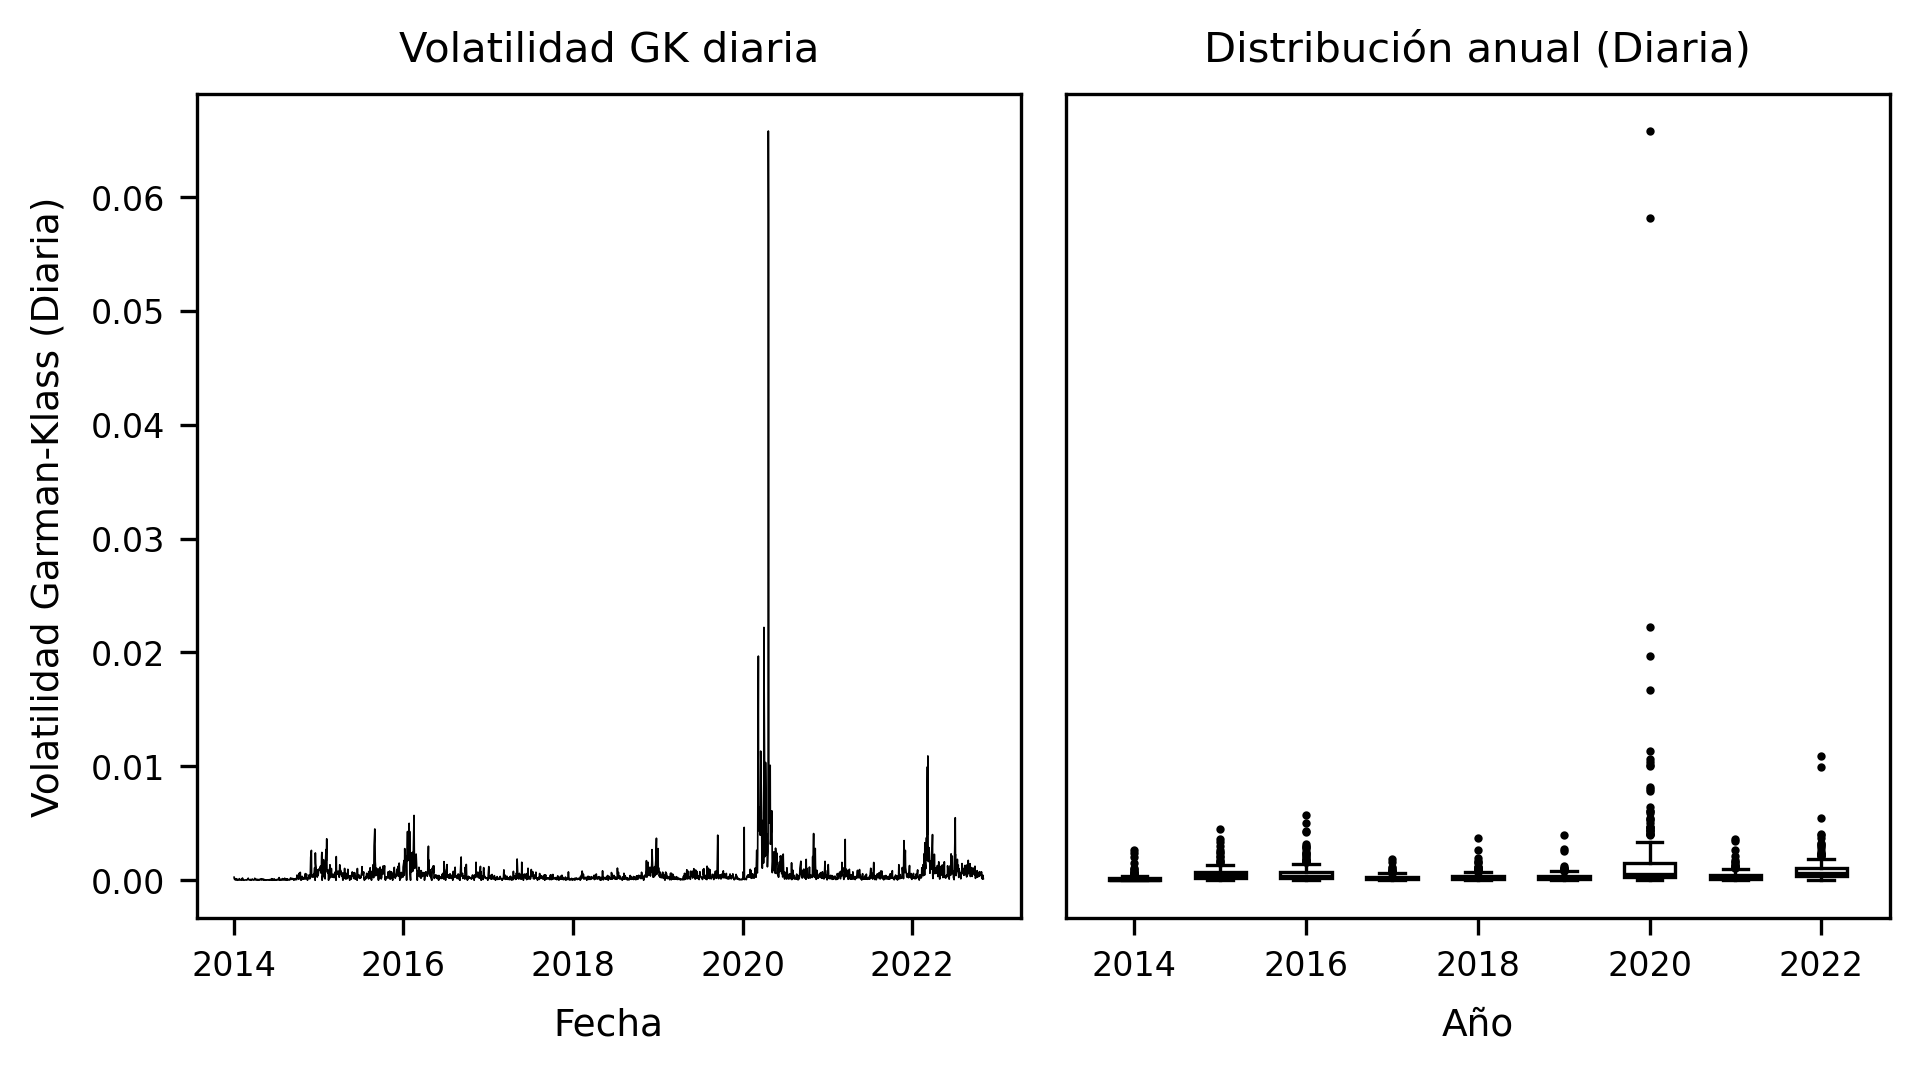

In [145]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Copia para graficar
df_plot = df_train.copy()
df_plot["year"] = df_plot.index.year

years = sorted(df_plot["year"].unique())
box_data_daily = [
    df_plot[df_plot["year"] == yr]["gk_daily"].dropna().values for yr in years
]

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(6.5, 3.8),
    dpi=300,
    subplot_kw={"box_aspect": 1},
)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelsize=8,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )

# Panel 1: Serie Temporal GK Diaria
ax1.plot(df_plot.index, df_plot["gk_daily"], color="black", linewidth=0.4)
ax1.set_xlabel("Fecha", fontsize=9, labelpad=6)
ax1.set_ylabel("Volatilidad Garman-Klass (Diaria)", fontsize=9, labelpad=6)
ax1.set_title("Volatilidad GK diaria", fontsize=10, pad=8)

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.tick_params(
    axis="y",
    which="both",
    left=True,
    labelsize=8,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

# Panel 2: Boxplots Anuales GK Diaria
bp = ax2.boxplot(
    box_data_daily,
    positions=years,
    widths=0.6,
    patch_artist=True,
    flierprops={
        "marker": "o",
        "markersize": 1.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markeredgewidth": 0.5,
    },
    boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
    whiskerprops={"color": "black", "linewidth": 0.8},
    capprops={"color": "black", "linewidth": 0.8},
    medianprops={"color": "black", "linewidth": 0.8},
)

even_years = [yr for yr in years if yr % 2 == 0]
ax2.set_xticks(even_years)
ax2.set_xticklabels(even_years, rotation=0)
ax2.set_xlim(min(years) - 0.8, max(years) + 0.8)

ax2.set_xlabel("Año", fontsize=9, labelpad=6)
ax2.set_title("Distribución anual (Diaria)", fontsize=10, pad=8)

ax2.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
    labelright=False,
)

plt.tight_layout()
plt.show()

In [67]:
# Preparar datos de volatilidad Garman-Klass
df_plot = df_train.dropna(subset=["gk_daily"]).copy()
gk = df_plot["gk_daily"]

# Suavizados móviles centrados
gk_5 = gk.rolling(window=5, center=True).mean()
gk_10 = gk.rolling(window=10, center=True).mean()
gk_21 = gk.rolling(window=21, center=True).mean()

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(9, 6), dpi=300)

# Estilo común
for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(
        axis="both",
        labelsize=9,
        direction="out",
        length=4,
        width=0.8,
        colors="black",
    )
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=9)

# Paneles: título y serie
panels = [
    ("Volatilidad Garman-Klass", gk),
    ("Volatilidad Garman-Klass (suavizado 5 días)", gk_5),
    ("Volatilidad Garman-Klass (suavizado 10 días)", gk_10),
    ("Volatilidad Garman-Klass (suavizado 21 días)", gk_21),
]

# Configurar paneles
for ax, (title, series) in zip(axes.flat, panels):
    ax.plot(series.index, series.values, color="black", linewidth=1.0)
    ax.set_title(title, fontsize=10, pad=9)
    ax.set_ylabel("Volatilidad GK", fontsize=10, labelpad=9)
    if ax in axes[1, :]:
        ax.set_xlabel("Fecha", fontsize=10, labelpad=9)
    else:
        ax.set_xlabel("")

# Formato de ticks
# Panel 1: 4 decimales (valores pequeños)
axes[0, 0].yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# Los demás paneles conservan límites automáticos
# Eje Y a la derecha para paneles derechos
for ax in [axes[0, 1], axes[1, 1]]:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

# Ajuste de espacio
fig.subplots_adjust(hspace=0.35, wspace=0.08)

render_figure_vector(fig)

In [72]:
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import HTML, display

# Preparar datos alineados
df_corr = df_train[["squared_returns", "gk_daily"]].dropna()
r2 = df_corr["squared_returns"]
gk = df_corr["gk_daily"]

# Suavizados móviles centrados
r2_5 = r2.rolling(window=5, center=True).mean()
r2_10 = r2.rolling(window=10, center=True).mean()
r2_21 = r2.rolling(window=21, center=True).mean()

gk_5 = gk.rolling(window=5, center=True).mean()
gk_10 = gk.rolling(window=10, center=True).mean()
gk_21 = gk.rolling(window=21, center=True).mean()

def corr_pair(x, y):
    x = x.dropna()
    y = y.loc[x.index]
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    return pearson_r, pearson_p, spearman_r, spearman_p

# Umbrales originales divididos por 4 comparaciones (Bonferroni)
alpha_1 = 0.05 / 4   # 0.0125
alpha_2 = 0.01 / 4   # 0.0025
alpha_3 = 0.001 / 4  # 0.00025

def format_stars(r, p):
    if p < alpha_3:
        stars = "***"
    elif p < alpha_2:
        stars = "**"
    elif p < alpha_1:
        stars = "*"
    else:
        stars = ""
    return f"{r:.3f}{stars}"

ventanas = {
    "Sin suavizar": (r2, gk),
    "5 días": (r2_5, gk_5),
    "10 días": (r2_10, gk_10),
    "21 días": (r2_21, gk_21),
}

rows = []
for nombre, (x, y) in ventanas.items():
    pear, p_pear, spear, p_spear = corr_pair(x, y)
    rows.append({
        "Ventana": nombre,
        "Pearson": format_stars(pear, p_pear),
        "Spearman": format_stars(spear, p_spear),
    })

df_corr_table = pd.DataFrame(rows)

styled_corr = (
    df_corr_table.style
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {"selector": "th:first-child", "props": [("text-align", "left")]},
        {"selector": "td:first-child", "props": [("text-align", "left")]},
    ])
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_corr.to_html()
        + "</div>"
    )
)

Ventana,Pearson,Spearman
Sin suavizar,0.681***,0.560***
5 días,0.820***,0.821***
10 días,0.879***,0.893***
21 días,0.929***,0.932***


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import ccf

# Preparar datos alineados
df_corr = df_train[["squared_returns", "gk_daily"]].dropna()
r2 = df_corr["squared_returns"]
gk = df_corr["gk_daily"]

# Suavizados
r2_5 = r2.rolling(window=5, center=True).mean()
r2_10 = r2.rolling(window=10, center=True).mean()
r2_21 = r2.rolling(window=21, center=True).mean()

gk_5 = gk.rolling(window=5, center=True).mean()
gk_10 = gk.rolling(window=10, center=True).mean()
gk_21 = gk.rolling(window=21, center=True).mean()

def compute_ccf(x, y, max_lag=20):
    x = x.dropna()
    y = y.loc[x.index]
    lags = np.arange(-max_lag, max_lag + 1)
    vals = np.zeros_like(lags, dtype=float)
    vals[lags >= 0] = ccf(x, y, adjusted=False)[:max_lag + 1]
    vals[lags < 0] = ccf(y, x, adjusted=False)[1:max_lag + 1][::-1]
    return lags, vals

variants = [
    ("Sin suavizar", r2, gk),
    ("Suavizado 5 días", r2_5, gk_5),
    ("Suavizado 10 días", r2_10, gk_10),
    ("Suavizado 21 días", r2_21, gk_21),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=300)

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.8)
    ax.tick_params(axis="both", labelsize=9, direction="out", length=4, width=0.8, colors="black")
    ax.grid(False)
    ax.set_ylim(-0.001, 1.00)
    ax.set_yticks(np.arange(0.0, 1.01, 0.1))
    ax.set_ylabel("Cross-correlation", fontsize=10, labelpad=7)

for idx, (ax, (title, x, y)) in enumerate(zip(axes.flat, variants)):
    lags, vals = compute_ccf(x, y)
    n = len(x)
    conf_level = 1.96 / np.sqrt(n)

    # Barras de CCF en negro
    ax.vlines(lags, ymin=0, ymax=vals, color="black", linewidth=1.0)

    # Línea central en negro
    ax.axhline(0, color="black", linewidth=0.5)

    # Bandas de confianza en azul saturado
    ax.axhline(conf_level, color="blue", linestyle="--", linewidth=1.0)
    ax.axhline(-conf_level, color="blue", linestyle="--", linewidth=1.0)

    ax.set_title(title, fontsize=12, pad=11)

    if idx < 2:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Retardo", fontsize=10, labelpad=7)

    # Paneles derechos: sin label y sin ticks del eje Y
    if idx % 2 == 1:
        ax.set_ylabel("")
        ax.tick_params(axis="y", which="both", left=False, labelleft=False)

fig.subplots_adjust(hspace=0.30, wspace=0.08)
render_figure_vector(fig)

In [85]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

# Preparar datos suavizados de 10 días
df_reg = pd.DataFrame({
    "r2_10": r2_10,
    "gk_10": gk_10,
}).dropna()

# Ordenar por fecha (ya debería estarlo)
df_reg = df_reg.sort_index()

# División cronológica 70% entrenamiento, 30% prueba
split_idx = int(len(df_reg) * 0.70)
train = df_reg.iloc[:split_idx]
test = df_reg.iloc[split_idx:]

# Estimar regresión en entrenamiento
X_train = sm.add_constant(train["r2_10"])
y_train = train["gk_10"]
model = sm.OLS(y_train, X_train).fit()
alpha = model.params["const"]
beta = model.params["r2_10"]

# Predecir en prueba
X_test = sm.add_constant(test["r2_10"])
y_pred = model.predict(X_test)
y_test = test["gk_10"]

# Calcular métricas fuera de muestra
r2_os = r2_score(y_test, y_pred)
rmse_os = np.sqrt(mean_squared_error(y_test, y_pred))

# Calcular R² dentro de muestra (para comparar)
y_train_pred = model.predict(X_train)
r2_is = r2_score(y_train, y_train_pred)

# Construir tabla de resultados
df_results = pd.DataFrame({
    "Métrica": ["R² dentro de muestra", "R² fuera de muestra", "RMSE fuera de muestra"],
    "Valor": [f"{r2_is:.4f}", f"{r2_os:.4f}", f"{rmse_os:.6f}"],
})

# Estilos CSS
styled_results = (
    df_results.style
    .hide(axis="index")
    .set_table_styles([
        {
            "selector": "",
            "props": [
                ("margin-left", "auto"),
                ("margin-right", "auto"),
                ("width", "auto"),
                ("border-collapse", "collapse"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black"),
                ("padding", "10px"),
            ],
        },
        {"selector": "th:first-child", "props": [("text-align", "left")]},
        {"selector": "td:first-child", "props": [("text-align", "left")]},
    ])
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_results.to_html()
        + "</div>"
    )
)

ModuleNotFoundError: No module named 'sklearn'

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Preparar datos suavizados de 10 días
df_reg = pd.DataFrame({
    "r2_10": r2_10,
    "gk_10": gk_10,
}).dropna()

# Ajustar regresión simple (MCO) para obtener la línea
X = sm.add_constant(df_reg["r2_10"])
model = sm.OLS(df_reg["gk_10"], X).fit()
alpha = model.params["const"]
beta = model.params["r2_10"]
r2 = model.rsquared

# Crear figura
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

# Estilo de ejes
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.tick_params(
    axis="both",
    labelsize=9,
    direction="out",
    length=4,
    width=0.8,
    colors="black",
)

# Puntos de dispersión
ax.scatter(df_reg["r2_10"], df_reg["gk_10"], s=10, color="black", alpha=0.6)

# Línea de regresión
x_vals = np.linspace(df_reg["r2_10"].min(), df_reg["r2_10"].max(), 100)
y_vals = alpha + beta * x_vals
ax.plot(x_vals, y_vals, color="blue", linewidth=1.5)

# Anotación con coeficientes y R²
texto = f"α = {alpha:.4f}\nβ = {beta:.4f}\nR² = {r2:.4f}"
ax.text(
    0.95,
    0.95,
    texto,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
)

# Etiquetas y título
ax.set_xlabel("Retorno al cuadrado (suavizado 10 días)", fontsize=10, labelpad=7)
ax.set_ylabel("Volatilidad GK (suavizado 10 días)", fontsize=10, labelpad=7)
ax.set_title("Regresión Mincer‑Zarnowitz (ventana 10 días)", fontsize=12, pad=11)

plt.tight_layout()
render_figure_vector(fig)